In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_excel("ApexPlanet_DataAnalytics_Dataset.xlsx")

print("Dataset Loaded Successfully")
print()

Dataset Loaded Successfully



In [7]:
print("Shape of Dataset")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

Shape of Dataset
(1000, 12)

Columns
Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age',
       'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price',
       'Total_Sales'],
      dtype='object')

First 5 Rows
    Order_ID  Order_Date Customer_ID Customer_Name   Age  Gender       City  \
0  ORD100002  2025-02-25    CUST5529  Customer_227  30.0  Female  Bengaluru   
1  ORD100003  2025-10-14    CUST3127  Customer_182  63.0    Male  Bengaluru   
2  ORD100004  2025-05-13    CUST8887  Customer_487  62.0  Female  Bengaluru   
3  ORD100005  2025-12-02    CUST2515  Customer_470  65.0  Female    Kolkata   
4  ORD100006  2025-11-20    CUST4796  Customer_380  44.0    Male  Bengaluru   

  Product     Category  Quantity  Unit_Price  Total_Sales  
0    Rice      Grocery         7     2829.77     19808.39  
1    Book    Education         5    27906.16    139530.80  
2    Book    Education         8    37491.06    299928.48  
3  Mobile  Electronics         9    28541.3

In [8]:
data_dictionary = pd.DataFrame({
    "Column_Name": df.columns,
    "Data_Type": df.dtypes.values
})

data_dictionary.to_excel(
    "Data_Dictionary.xlsx",
    index=False
)

print("\nData Dictionary Saved")



Data Dictionary Saved


In [9]:
print("\nMissing Values")
print(df.isnull().sum())

missing_percent = (
    df.isnull().sum() / len(df)
) * 100

print("\nMissing Percentage")
print(missing_percent)


Missing Values
Order_ID          0
Order_Date        0
Customer_ID       0
Customer_Name     0
Age              20
Gender            0
City             13
Product           0
Category          0
Quantity          0
Unit_Price        0
Total_Sales       0
dtype: int64

Missing Percentage
Order_ID         0.0
Order_Date       0.0
Customer_ID      0.0
Customer_Name    0.0
Age              2.0
Gender           0.0
City             1.3
Product          0.0
Category         0.0
Quantity         0.0
Unit_Price       0.0
Total_Sales      0.0
dtype: float64


In [10]:
# Age -> Median

df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

# Categorical Columns -> Mode

categorical_columns = [
    "Gender",
    "City",
    "Product",
    "Category"
]

for col in categorical_columns:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

print("\nMissing Values After Cleaning")
print(df.isnull().sum())



Missing Values After Cleaning
Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
Age              0
Gender           0
City             0
Product          0
Category         0
Quantity         0
Unit_Price       0
Total_Sales      0
dtype: int64


In [11]:
print("\nDuplicate Rows")
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("\nDuplicates Removed")


Duplicate Rows
0

Duplicates Removed


In [12]:
text_columns = [
    "Customer_Name",
    "Gender",
    "City",
    "Product",
    "Category"
]

for col in text_columns:

    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.title()
    )

print("\nText Formatting Standardized")


Text Formatting Standardized


In [13]:
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"]
)

print("\nDate Conversion Complete")



Date Conversion Complete


In [16]:
df["Month"] = (
    df["Order_Date"]
    .dt.month_name()
)

# Year

df["Year"] = (
    df["Order_Date"]
    .dt.year
)

# Quarter

df["Quarter"] = (
    df["Order_Date"]
    .dt.quarter
)

# Revenue Segment

def revenue_segment(sales):

    if sales < 50000:
        return "Low"

    elif sales < 150000:
        return "Medium"

    else:
        return "High"

df["Revenue_Segment"] = (
    df["Total_Sales"]
    .apply(revenue_segment)
)

# Age Group

def age_group(age):

    if age < 25:
        return "Young"

    elif age < 40:
        return "Adult"

    elif age < 60:
        return "Middle Age"

    else:
        return "Senior"

df["Age_Group"] = (
    df["Age"]
    .apply(age_group)
)

# High Value Customer

df["High_Value_Customer"] = np.where(
    df["Total_Sales"] > 100000,
    "Yes",
    "No"
)

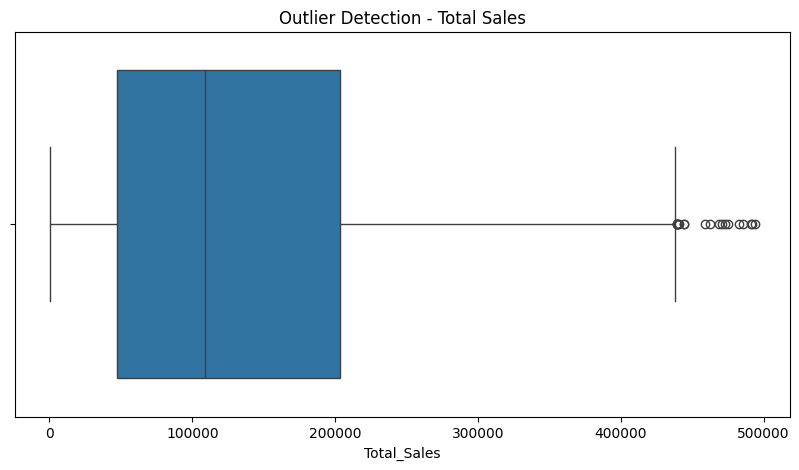

In [17]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["Total_Sales"]
)

plt.title(
    "Outlier Detection - Total Sales"
)

plt.show()


In [18]:
Q1 = df["Total_Sales"].quantile(0.25)

Q3 = df["Total_Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

df = df[
    (
        df["Total_Sales"] >= lower_bound
    )
    &
    (
        df["Total_Sales"] <= upper_bound
    )
]

print("\nOutliers Removed")


Outliers Removed


In [19]:
print("\nFinal Shape")
print(df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nFinal Dataset Info")
print(df.info())


Final Shape
(981, 18)

Missing Values
Order_ID               0
Order_Date             0
Customer_ID            0
Customer_Name          0
Age                    0
Gender                 0
City                   0
Product                0
Category               0
Quantity               0
Unit_Price             0
Total_Sales            0
Month                  0
Year                   0
Quarter                0
Revenue_Segment        0
Age_Group              0
High_Value_Customer    0
dtype: int64

Duplicate Rows
0

Final Dataset Info
<class 'pandas.core.frame.DataFrame'>
Index: 981 entries, 0 to 999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order_ID             981 non-null    object        
 1   Order_Date           981 non-null    datetime64[ns]
 2   Customer_ID          981 non-null    object        
 3   Customer_Name        981 non-null    object        
 4   Age          

In [20]:
df.to_excel(
    "Cleaned_Sales_Dataset.xlsx",
    index=False
)

print("\nCleaned Dataset Saved Successfully")


Cleaned Dataset Saved Successfully


In [21]:
print("\nCleaned Dataset Preview")

print(df.head())


Cleaned Dataset Preview
    Order_ID Order_Date Customer_ID Customer_Name   Age  Gender       City  \
0  ORD100002 2025-02-25    CUST5529  Customer_227  30.0  Female  Bengaluru   
1  ORD100003 2025-10-14    CUST3127  Customer_182  63.0    Male  Bengaluru   
2  ORD100004 2025-05-13    CUST8887  Customer_487  62.0  Female  Bengaluru   
3  ORD100005 2025-12-02    CUST2515  Customer_470  65.0  Female    Kolkata   
4  ORD100006 2025-11-20    CUST4796  Customer_380  44.0    Male  Bengaluru   

  Product     Category  Quantity  Unit_Price  Total_Sales     Month  Year  \
0    Rice      Grocery         7     2829.77     19808.39  February  2025   
1    Book    Education         5    27906.16    139530.80   October  2025   
2    Book    Education         8    37491.06    299928.48       May  2025   
3  Mobile  Electronics         9    28541.36    256872.24  December  2025   
4    Rice      Grocery        10    14036.59    140365.90  November  2025   

   Quarter Revenue_Segment   Age_Group High